In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np, sys, os, pathlib

REPO_DIR = pathlib.Path(os.path.dirname(os.path.abspath(os.getcwd()))); print(f"Repo: {str(REPO_DIR)}")
sys.path.insert(0, str(REPO_DIR / "src"))

from traffic_flow.pipeline import simulate_scenario
from traffic_flow.reporting.plotter import Plotter
from traffic_flow.types import *
from traffic_flow.reporting.plots import plot_velocity_comparison

Repo: /Users/tristanchaang/MIT/UROP-Traffic/mpc-traffic-flow


## Data and Calibration loading

In [ ]:
# # Setup freeway info
# from data_loader import Freeway

# FREEWAY = "i24"
# DATE = "11_30"
# time_steps, num_segments = 360, 14
# L: km = 0.4
# time_step: hr = 10/3600
# start_time: hr = 0.0
# start_time_step = 0

# freeway = Freeway(FREEWAY, DATE, L, num_segments, time_step, time_steps, start_time)

# start_time_step = freeway.start_time_step

### Load data & calibrated parameters

In [ ]:
# # Read in the data
# CONSTRAINT = "" # or "speed_lb", "hold_length", "safety_sweep"
# SPEED_LBS = [0]
# assert(CONSTRAINT == "" or SPEED_LBS == [0])
# calibration_id = "calibration_static/fixed_ramping" # default: "calibration_static/fixed_ramping"
# calibration_interval = None # None if static, else interval in time steps

# traffic = freeway.load_real_data()
# p_data, q_data, v_data, lane_cts, data_inflow, downstream_density, p_init, v_init = traffic
# results_path = freeway.results_path(calibration_id, calibration_interval, CONSTRAINT)
# model_params = freeway.get_params(calibration_id, calibration_interval)

No dynamic parameter subfolders found — using static calibration parameters


In [ ]:
# from scenario import ScenarioConfig, load_scenario

# scenario_config = ScenarioConfig(
#     freeway=FREEWAY,
#     date=DATE,
#     L=L,
#     num_segments=num_segments,
#     time_step=time_step,
#     time_steps=time_steps,
#     start_time=start_time,
#     calibration_id=calibration_id,
#     calibration_interval=calibration_interval,
# )

# _, traffic, model_params, results_path = load_scenario(
#     scenario_config, constraint=CONSTRAINT
# )
# p_data, q_data, v_data, lane_cts, data_inflow, downstream_density, p_init, v_init = traffic

In [ ]:
from traffic_flow.config import CalRef, CalSource
from traffic_flow.inputs.scenario import load_params, load_scenario
from traffic_flow.results.io import result_dir

CONSTRAINT = ""
SPEED_LBS = [0]
assert CONSTRAINT == "" or SPEED_LBS == [0]

CALIBRATION = CalRef(CalSource.FIXED_RAMPS)
loaded = load_scenario("i24", "11_30")
scenario_config = loaded.spec
traffic = loaded.traffic
model_params = load_params(loaded, calibration=CALIBRATION)
results_path = result_dir(scenario_config.freeway, scenario_config.date, calibration=CALIBRATION, study=CONSTRAINT)

# Aliases retained for the existing simulation and plotting cells.
L = scenario_config.L
time_step = scenario_config.time_step
time_steps = scenario_config.time_steps
num_segments = scenario_config.num_segments
start_time_step = int(scenario_config.start_time / time_step)

(p_data, q_data, v_data, lane_cts, data_inflow, 
 downstream_density, p_init, v_init) = traffic

time_step:		 10.0 seconds
time_steps:		 360
num_segments:		 14
sim_time:		 60.0 minutes
length of highway:	 5.6000000000000005 km


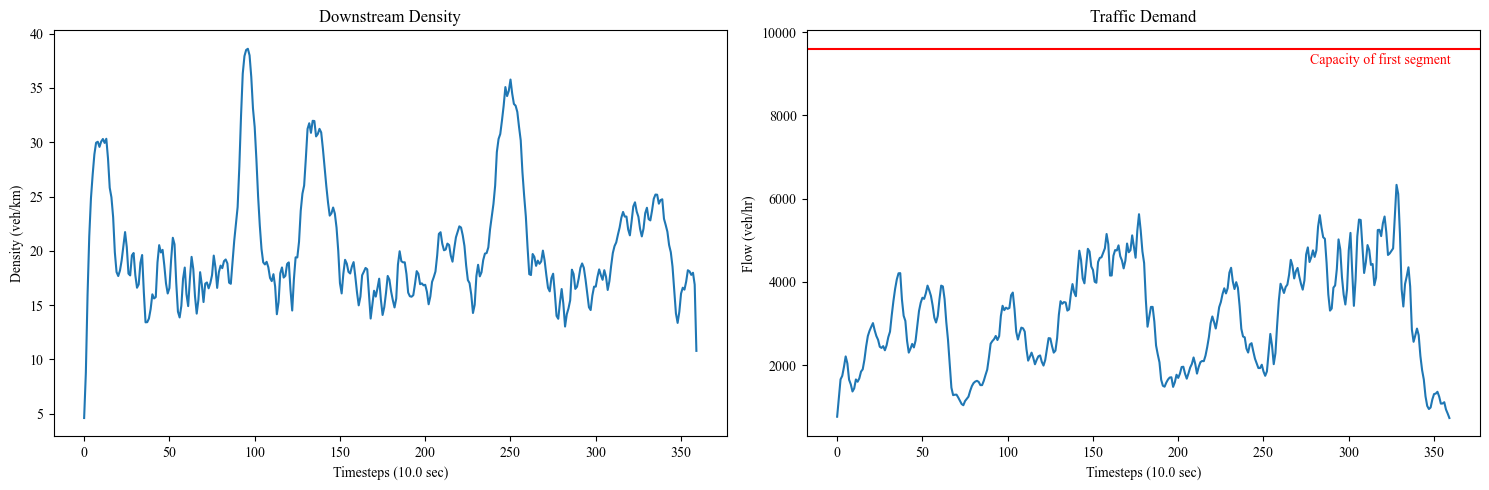

In [43]:
lane_dict: lane_map = {i: lane_count for i, lane_count in enumerate(lane_cts)}
total_distance = L * num_segments

print("time_step:\t\t", time_step * 3600, "seconds")
print("time_steps:\t\t", time_steps)
print("num_segments:\t\t", num_segments)
print("sim_time:\t\t", time_step * time_steps * 60, "minutes")
print("length of highway:\t", total_distance, "km")

p = Plotter(1, 2)
p[0] = {'title': 'Downstream Density', 'xlabel': f'Timesteps ({time_step*3600} sec)', 'ylabel': 'Density (veh/km)'}
p[0].plot(downstream_density)
p[1] = {'title': 'Traffic Demand', 'xlabel': f'Timesteps ({time_step*3600} sec)', 'ylabel': 'Flow (veh/hr)'}
p[1].plot(data_inflow)
p[1].axhline(2400 * lane_dict[0], c='red')
p[1].text(x=len(data_inflow), y=2400 * lane_dict[0]-100, s="Capacity of first segment", va="top", ha="right", color="red")
p.show()

## Simulations

### without Control

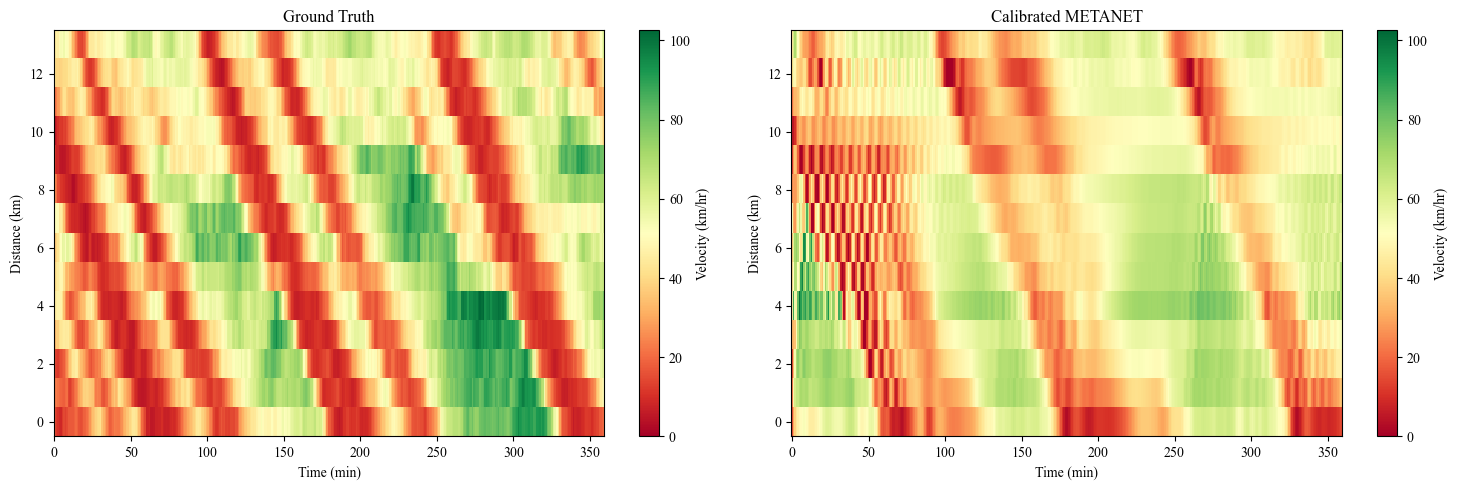

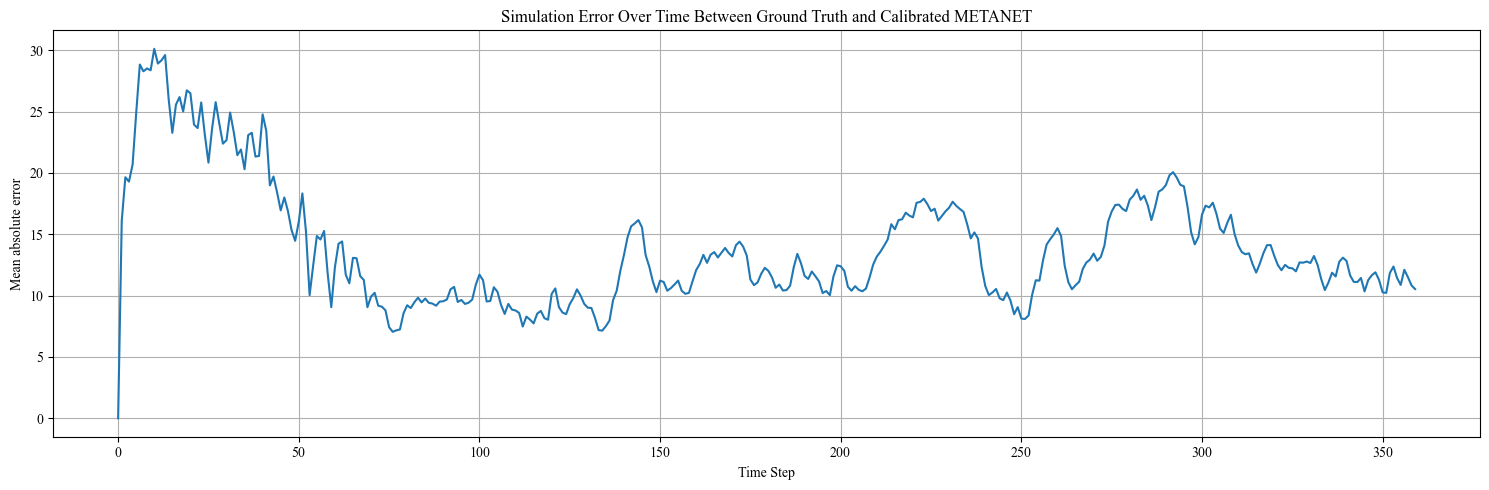

Ground Truth vs METANET
Velocity:	 (mape 58.06 %, rmse 17.68)
Density:	 (mape 33.85 %, rmse 9.1)
Flow:   	 (mape 52.89 %, rmse 1751.24)
Travel Time:	 562.15 veh-hr vs 549.26 veh-hr (mape 2.29 %)


In [ ]:
p_sim, v_sim, _, _ = simulate_scenario(
  traffic, model_params,
  T=time_step, l=L,
  steps=time_steps,
  real_data=True,
)
p_sim: time_space = p_sim[:-1, :]
v_sim: time_space = v_sim[:-1, :]

# Read in v_pred.npy from the path location
p = plot_velocity_comparison(observed=v_data[start_time_step:], simulated=v_sim)
p.show()

flow_sim = v_sim * p_sim * lane_cts

print("Ground Truth vs METANET")
def mape(y_true, y_pred): return np.mean(np.abs((y_true - y_pred) / y_true) * 100)
def rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred) ** 2))
for qt, y, y_pred in [('Velocity', v_data, v_sim), ('Density', p_data, p_sim), ('Flow', q_data, flow_sim)]:
  print(f"{qt+':':<8}\t (mape {round(mape(y, y_pred), 2)} %, rmse {round(rmse(y, y_pred), 2)})")

gt_tt, metanet_tt = (time_step * L * (np.sum(rhos * lane_cts[np.newaxis,:])) for rhos in [p_data, p_sim])
print(f"Travel Time:\t {gt_tt:.2f} veh-hr vs {metanet_tt:.2f} veh-hr (mape {(np.abs(gt_tt - metanet_tt) / gt_tt * 100):.2f} %)")

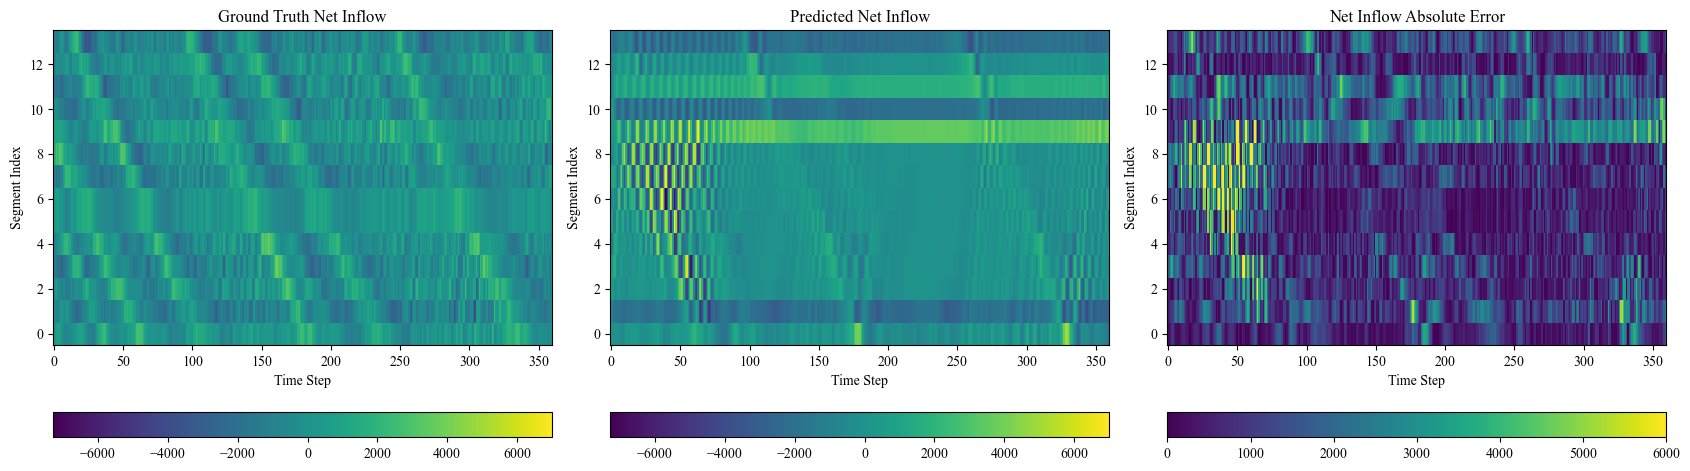

In [45]:
def get_velocity_heatmap(v_hat, v_pred, q_hat, q_pred, rho_hat, rho_pred):
    shortened_v_hat = v_hat
    shortened_rho_hat = rho_hat
    # Determine some set of 3 scalars for each of q, rho, v to make a unified map
    v_diff = np.abs(shortened_v_hat - v_pred)/shortened_v_hat
    rho_diff = np.abs(shortened_rho_hat - rho_pred)/shortened_rho_hat 
    diff = v_diff + rho_diff

    p = Plotter(1, 2)
    p.fig.colorbar(p[0].imshow(diff.T, cmap='viridis', aspect='auto', interpolation='none', vmin=0, vmax=1), ax=p[0])
    p.fig.colorbar(p[1].imshow(shortened_v_hat.T, cmap='RdYlGn', aspect='auto', interpolation='none'), ax=p[1])
    p[0] = {'title': 'Combined Normalized Difference Heatmap'}
    p[1] = {'title': 'Ground Truth Velocity Heatmap'}
    for i, ax in enumerate(p):
        p[i] = {'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
        ax.invert_yaxis()
    p.show()

# Calculate the error on the net_inflow
net_q_hat, net_q_pred = (-np.diff(q, axis=1, prepend=data_inflow[:, np.newaxis]) for q in [q_data, flow_sim])
mape = np.abs(net_q_hat - net_q_pred)

net_q_min = min(net_q_hat.min(), net_q_pred.min())
net_q_max = max(net_q_hat.max(), net_q_pred.max())

p = Plotter(1, 3)
p.fig.colorbar(p[0].imshow(net_q_hat.T, cmap='viridis', aspect='auto', interpolation='none', vmin=net_q_min, vmax=net_q_max),
    ax=p[0], orientation='horizontal')
p.fig.colorbar(p[1].imshow(net_q_pred.T, cmap='viridis', aspect='auto', interpolation='none', vmin=net_q_min, vmax=net_q_max),
    ax=p[1], orientation='horizontal')
p.fig.colorbar(p[2].imshow(mape.T, cmap='viridis', aspect='auto', interpolation='none', vmax=6000),
    ax=p[2], orientation='horizontal')
p[0] = {'title': 'Ground Truth Net Inflow'}
p[1] = {'title': 'Predicted Net Inflow'}
p[2] = {'title': 'Net Inflow Absolute Error'}
for i, ax in enumerate(p):
    p[i] = {'xlabel': 'Time Step', 'ylabel': 'Segment Index'}
    p[i].invert_yaxis()
p.show()


### with constant VSL control

TTS (VSL=100): 748.73 veh-hr
TTS (VSL=150): 550.63 veh-hr


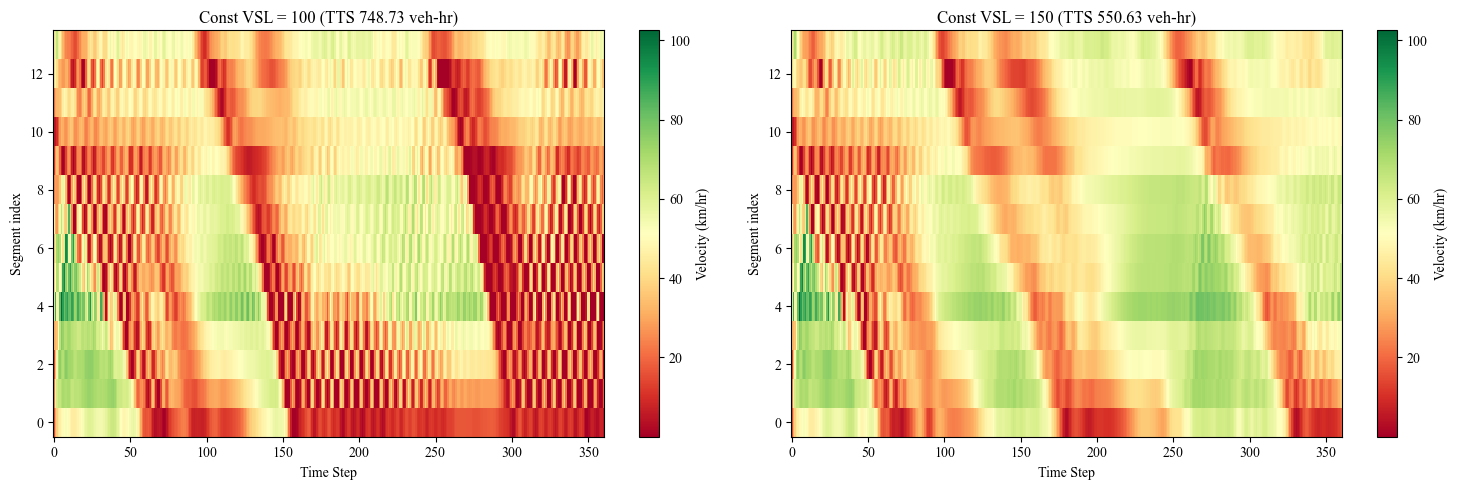

In [ ]:
# simulate with constant VSL = 130 and VSL = 150, then plot side-by-side heatmaps
const_vsls = [100, 150]

ps, vs, qs, ttss = zip(*(simulate_scenario(
      traffic, model_params,
      T=time_step, l=L,
      steps=time_steps,
      vsl=np.full((time_steps, num_segments), speed, dtype=float),
      real_data=False,
    ) 
  for speed in const_vsls))

for vsl, tts in zip(const_vsls, ttss):
    print(f"TTS (VSL={vsl}): {tts:.2f} veh-hr")

# consistent color scale
vmin = min(v_data[:, 1:-1].min(), np.array(vs).min())
vmax = max(v_data[:, 1:-1].max(), np.array(vs).max())

p = Plotter(1, 2)
for i, (v_mat, sl, tts) in enumerate(zip(vs, const_vsls, ttss)):
  p.fig.colorbar(
      mappable=p[i].imshow(v_mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=vmin, vmax=vmax),
      ax=p[i], label='Velocity (km/hr)'
  )
  p[i] = {'title': f'Const VSL = {sl} (TTS {np.round(tts, 2)} veh-hr)', 'xlabel': 'Time Step', 'ylabel': 'Segment index'}
  p[i].invert_yaxis()
p.show()


### with Optimized Control

In [ ]:
pred_horizon = 45  # in time steps
control_horizon = 5 # in time steps
hold_len = 1

(360,) ---padding--> (402,)


In [ ]:
import json
import logging
from dataclasses import asdict
from traffic_flow.config import MPCConfig
from traffic_flow.pipeline import optimize_scenario
from traffic_flow.results.io import save_policy

logging.getLogger("pyomo.core").setLevel(logging.ERROR)

if start_time_step != 0:
    raise NotImplementedError("Nonzero start-time alignment has not been migrated yet.")

for speed_lb in SPEED_LBS:
    config = MPCConfig(
        pred_horizon=pred_horizon,
        control_horizon=control_horizon,
        hold_length=hold_len,
        speed_lb=speed_lb,
        v_fd_penalty=1e14,
        control_zone=tuple(range(2, num_segments)),
        verbose=True,
        init_fixed = 150.0
    )

    optimization_result = optimize_scenario(
        traffic,
        model_params,
        T=time_step,
        l=L,
        config=config,
        steps=time_steps,
    )
    save_policy(
        results_path, optimization_result.vsl, config,
        scenario=scenario_config,
        calibration=CALIBRATION,
        constraint=CONSTRAINT,
    )

Starting optimization... 
MPC t=320 | fully cold: 100%|██████████| 360/360 [11:25<00:00,  1.90s/step]               
[MPC] Done. Total CPU: 10.3s  Avg/solve: 0.13s
(360, 14)


In [49]:
print(model_params['v_free'])

[ 87.10210005  83.42995873  71.50486178  70.          94.17244619
  70.          89.51853108  70.          70.          95.13600776
  70.          70.         117.46739304 149.99999998]


In [50]:
# Print ramp info
print("Ramp info")
print("lane count:\t", [round(lane_dict[i], 2) for i in range(num_segments)])
print("on-ramp:\t", [int(model_params['r'][i] > 0.001) for i in range(num_segments)])
print("off-ramp:\t", [int(model_params['beta'][i] > 0.001) for i in range(num_segments)])

Ramp info
lane count:	 [4.0, 4.0, 4.0, 4.35, 5.0, 5.0, 5.0, 5.0, 4.86, 4.0, 4.0, 4.05, 4.51, 4.0]
on-ramp:	 [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1]
off-ramp:	 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0]


## Plotting Controlled Result

In [ ]:
p_baseline, v_baseline, _, tts_baseline = optimization_result.baseline
p_opt, v_opt, queue, tts_opt = optimization_result.controlled

print(f"{tts_baseline:.2f} veh-hr → {tts_opt:.2f} veh-hr")

assert np.allclose(queue, 0), "Queue is not zero, something went wrong with the optimization or simulation"

550.63 veh-hr ---optimal---> 383.42 veh-hr


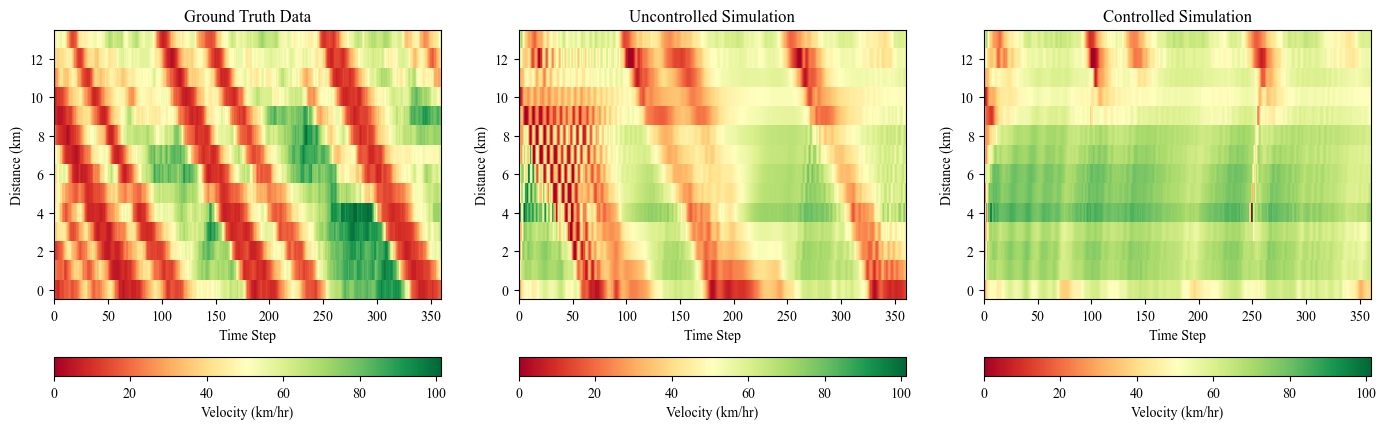

In [52]:
# Read in v_pred.npy from the path location
max_v = max(np.max(v_baseline), np.max(v_opt)).item()

p = Plotter(1, 3)
for i, mat in enumerate([v_data, v_baseline, v_opt]):
  p.fig.colorbar(
      mappable=p[i].imshow(mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v),
      ax=p[i], label='Velocity (km/hr)', orientation='horizontal' 
  )
  p[i] = {'xlabel': 'Time Step', 'ylabel': 'Distance (km)'}
  p[i].invert_yaxis()
p[0] = {'title': 'Ground Truth Data'}
p[1] = {'title': 'Uncontrolled Simulation'}
p[2] = {'title': 'Controlled Simulation'}
p.savefig(REPO_DIR / "figs" / "test", dpi=150, bbox_inches='tight')

In [53]:
from traffic_flow.metrics import get_ff_tts

ff_ttt = get_ff_tts(data_inflow, time_step, L, model_params['v_free'])
print(f"Total free flow travel time: {ff_ttt:.2f} veh-hrs")
delay  = tts_baseline - ff_ttt
opt_delay = tts_opt - ff_ttt
print(f"Controllable congestion: {(delay - opt_delay) / delay * 100:.2f}%")

Total free flow travel time: 214.24 veh-hrs
Controllable congestion: 49.71%


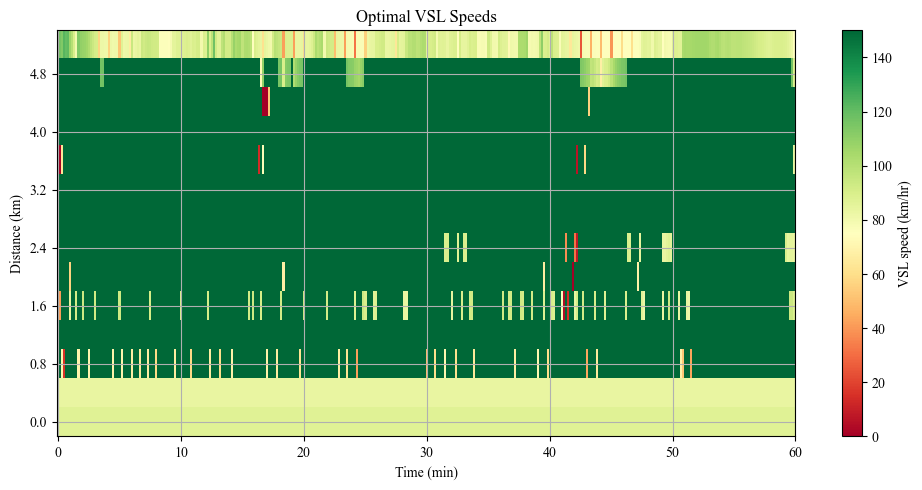

In [ ]:
from traffic_flow.reporting.plots import plot_vsls
from traffic_flow.results.io import load_policy

optimal_vsl = load_policy(results_path, constraint=CONSTRAINT, speed_lb=speed_lb)
display_vsl = np.where(optimal_vsl > model_params["v_free"], 150, optimal_vsl)
plot_vsls(display_vsl, time_steps + 1, num_segments, model_params["v_free"].max(), T=time_step, l=L)

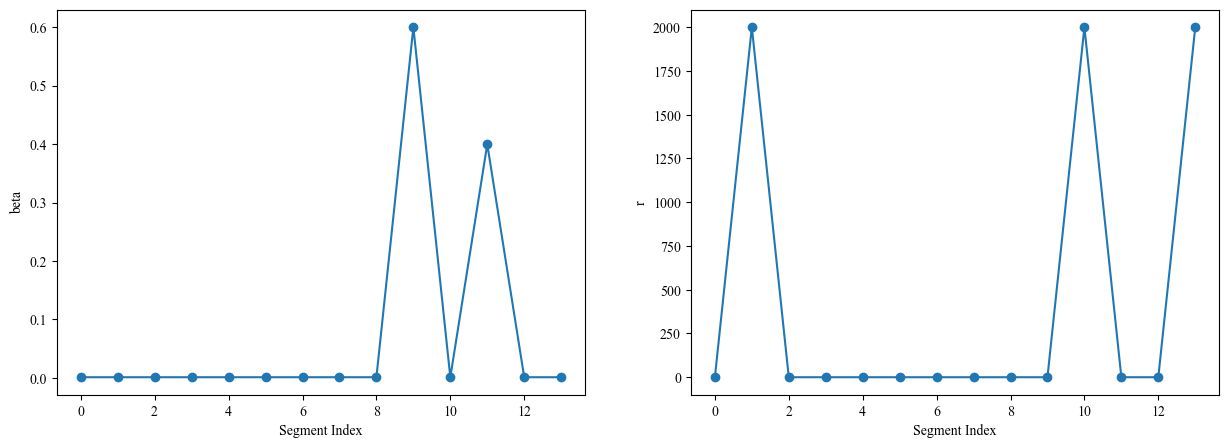

In [55]:
p = Plotter(1, 2)
for i, variable in enumerate(['beta', 'r']):
  p[i] = {'xlabel': 'Segment Index', 'ylabel': variable}
  p[i].plot(model_params[variable], marker='o')

min and max delay (ground truth): -0.10067403801637502 7.3622940475497
min and max pct decrease: 471.4447034241984 -230311368.29960313


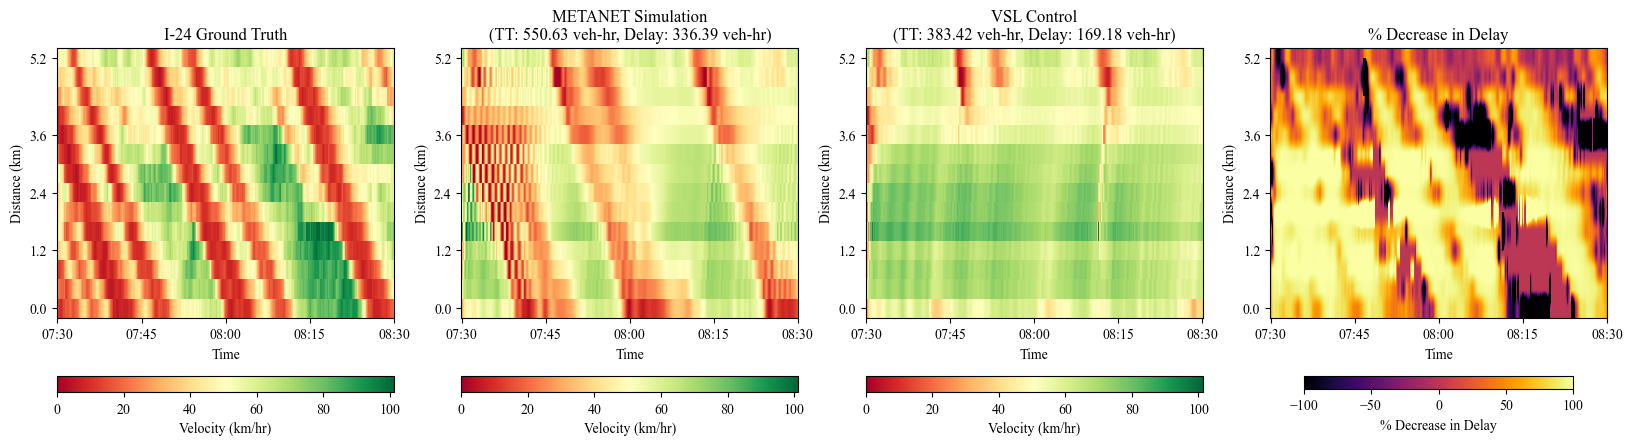

In [ ]:
start_wallclock_time = 7.5 # 7

n_time = v_data.shape[0] +1
minutes = np.arange(n_time) * time_step * 60
tick_pos = np.linspace(0, n_time - 1, 5, dtype=int)

def format_time(start_hour, minutes):
    hour, minute = divmod(int(start_hour * 60 + minutes), 60)
    return f"{hour % 24:02d}:{minute:02d}"

tick_labels = [format_time(start_wallclock_time, m) for m in minutes[tick_pos]]

# Compute y ticks in km — add this before the imshow calls
n_segments = v_data.shape[1]
ytick_pos = np.linspace(0, n_segments - 1, 5, dtype=int)
ytick_labels = [f"{i * 0.4:.1f}" for i in ytick_pos]  # 400m per segment → km

# pointwise delay
# --- Compute Delay ---
# free_flow_speed shape: (n_segments,) → reshape to (n_segments, 1) to broadcast over time
free_flow_speed_2d = np.array(model_params['v_free'])[:, np.newaxis]  # or .reshape(-1, 1)

delay_gt        = (0.4 / v_data.T - 0.4 / free_flow_speed_2d) * 60
delay_noctrl    = (0.4 / v_baseline[0:-1, :].T - 0.4 / free_flow_speed_2d) * 60
delay_ctrl      = (0.4 / v_opt[0:-1, :].T - 0.4 / free_flow_speed_2d) * 60

print('min and max delay (ground truth):', np.min(delay_gt), np.max(delay_gt))

pct_decrease = np.where(delay_gt > 0.01, (delay_gt - delay_ctrl) / delay_gt * 100, 0)
print('min and max pct decrease:', np.max(pct_decrease), np.min(pct_decrease))

p = Plotter(1, 4)
for i, mat in enumerate([v_data, v_baseline, v_opt]):
  p.fig.colorbar(
    mappable=p[i].imshow(mat.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max_v),
    ax=p[i], label='Velocity (km/hr)', orientation='horizontal'
  )
p.fig.colorbar(
    mappable=p[3].imshow(pct_decrease, cmap='inferno', aspect='auto', vmin=-100, vmax=100),
    ax=p[3], label='% Decrease in Delay', orientation='horizontal', location='bottom', pad=0.15, shrink=0.8, aspect=20
)
for i, ax in enumerate(p):
  p[i] = {'xlabel': 'Time', 'ylabel': 'Distance (km)', 'xticks': tick_pos, 'yticks': ytick_pos, 
          'xticklabels': tick_labels, 'yticklabels': ytick_labels}
  p[i].invert_yaxis()

p[0] = {'title': f'I-24 Ground Truth'}
p[1] = {'title': f'METANET Simulation\n(TT: {np.round(tts_baseline, 2)} veh-hr, Delay: {np.round(delay, 2)} veh-hr)'}
p[2] = {'title': f'VSL Control\n(TT: {np.round(tts_opt, 2)} veh-hr, Delay: {np.round(opt_delay, 2)} veh-hr)'}
p[3] = {'title': f'% Decrease in Delay'}

p.show()

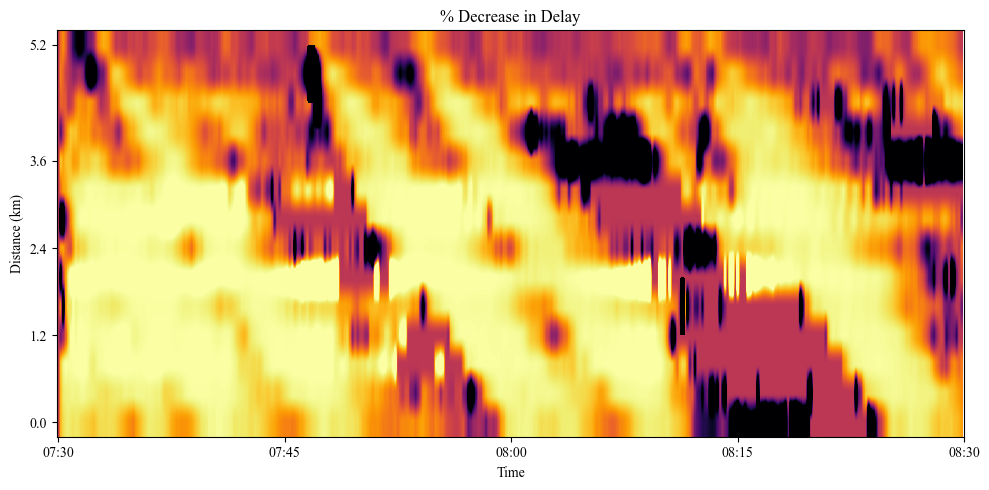

In [57]:
# Plot just the percent decrease in delay
p = Plotter(1, 1)

p[0].imshow(pct_decrease, cmap='inferno', aspect='auto', vmin=-100, vmax=100)
p[0].invert_yaxis()
p[0] = {'xlabel': 'Time', 'ylabel': 'Distance (km)', 'xticks': tick_pos, 'yticks': ytick_pos, 
          'xticklabels': tick_labels, 'yticklabels': ytick_labels, 'title': f'% Decrease in Delay'}
p.show()